In [7]:
# ================================================================
# CELL 1: Install Required Libraries
# ================================================================
!pip install -q transformers peft pandas Pillow torchvision tqdm
!pip install --upgrade torchao
print("Libraries installed successfully!")



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\Charlene C. Dilig\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


Libraries installed successfully!



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\Charlene C. Dilig\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [8]:
# ================================================================
# CELL 2: Load the Test Data
# ================================================================
import os
import pandas as pd
from PIL import Image

CSV_PATH = '../captions/dataset_captionsV2.csv'
IMG_DIR  = '../images'

df = pd.read_csv(CSV_PATH)

# 1. BUILD THE MASSIVE GALLERY (Train + Val + Test)
gallery_images = []
gallery_item_names = []

print("Loading entire database of images (Distractors + Targets)...")
for idx, row in df.iterrows():
    img_path = os.path.join(IMG_DIR, row['found_image'])
    gallery_images.append(Image.open(img_path).convert('RGB'))
    gallery_item_names.append(row['pair_id'])

print(f"Gallery Size: {len(gallery_images)} total images.")

# 2. ISOLATE THE TEST QUERIES
test_df = df[df['split'] == 'test'].reset_index(drop=True)
queries = []
test_item_names = []

for idx, row in test_df.iterrows():
    queries.append(row['positive_caption'])
    test_item_names.append(row['pair_id'])

num_test_items = len(test_df)
print(f"Test Queries: {num_test_items} text descriptions.")


Loading entire database of images (Distractors + Targets)...
Gallery Size: 600 total images.
Test Queries: 90 text descriptions.


In [9]:
# ================================================================
# CELL 3: Load Base Model + Both LoRA Adapters
#
#   Ensemble: V2.1+HNM (single-image) + CLAUDE V2.1+HNM (dual-image)
#   Both models share the same base (qihoo360/fg-clip-base, ViT-B/16).
#   Evaluation uses single-image encoding for both (found_image only).
#   The dual-image nature of CLAUDE only affects how it was trained.
#   Combination: element-wise average of similarity matrices (CELL 5).
# ================================================================
import torch
from transformers import CLIPProcessor, CLIPModel
from peft import PeftModel

base_model_id = "qihoo360/fg-clip-base"
print(f"Downloading Base Model: {base_model_id}...")

processor  = CLIPProcessor.from_pretrained(base_model_id)
base_model = CLIPModel.from_pretrained(base_model_id)

# --- Model A: V2.1 + HNM (single-image training) ---
adapter_path_A = "../lorafinetuned/fgclip-lora-finetunedV2.1-1200-HNM"
print(f"Loading Model A: {adapter_path_A}...")
model_A = PeftModel.from_pretrained(base_model, adapter_path_A)
print(f"  Model A loaded.")

# --- Model B: CLAUDE V2.1 + HNM (dual-image training) ---
#   Re-load base to avoid adapter merge conflicts
base_model_B = CLIPModel.from_pretrained(base_model_id)
adapter_path_B = "../lorafinetuned/CLAUDEfgclip-lora-finetunedV2.1-1200-HNM"
print(f"Loading Model B: {adapter_path_B}...")
model_B = PeftModel.from_pretrained(base_model_B, adapter_path_B)
print(f"  Model B loaded.")

device = "cuda" if torch.cuda.is_available() else "cpu"
model_A.to(device)
model_A.eval()
model_B.to(device)
model_B.eval()

print(f"")
print(f"Both models loaded and ready for retrieval!")
print(f"   Model A: fgclip-lora-finetunedV2.1-1200-HNM     (single-image training)")
print(f"   Model B: CLAUDEfgclip-lora-finetunedV2.1-1200-HNM (dual-image training)")


Loading Model A: ../lorafinetuned/fgclip-lora-finetunedV2.1-1200-HNM...
  Model A loaded.
Loading Model B: ../lorafinetuned/CLAUDEfgclip-lora-finetunedV2.1-1200-HNM...
  Model B loaded.

Both models loaded and ready for retrieval!
   Model A: fgclip-lora-finetunedV2.1-1200-HNM     (single-image training)
   Model B: CLAUDEfgclip-lora-finetunedV2.1-1200-HNM (dual-image training)


In [10]:
# ================================================================
# CELL 4: Configuration Summary
# ================================================================
print("")
print("="*60)
print("ENSEMBLE CONFIGURATION")
print("="*60)
print(f"  Base Model:              {base_model_id}")
print(f"  Device:                  {device}")
print(f"")
print(f"  --- Model A (Single-Image Training) ---")
print(f"  Adapter:                 fgclip-lora-finetunedV2.1-1200-HNM")
print(f"  Training loss:           Single-image (1 caption + 1 image)")
print(f"  LoRA rank (r):           32")
print(f"  LoRA alpha (alpha):     128")
print(f"  Learning rate:           3e-5")
print(f"")
print(f"  --- Model B (Dual-Image Training) ---")
print(f"  Adapter:                 CLAUDEfgclip-lora-finetunedV2.1-1200-HNM")
print(f"  Training loss:           Dual-image (1 caption + 2 images)")
print(f"  LoRA rank (r):           32")
print(f"  LoRA alpha (alpha):     128")
print(f"  Learning rate:           3e-5")
print(f"")
print(f"  --- Ensemble Method ---")
print(f"  Strategy:                Element-wise similarity matrix average")
print(f"  Formula:                 sim_ensemble = (sim_A + sim_B) / 2")
print(f"  Evaluation images:       Single found_image per item (both models)")
print(f"")
print(f"  --- Dataset ---")
print(f"  Gallery size:           {len(gallery_images)}")
print(f"  Test queries:           {num_test_items}")
print("="*60)



ENSEMBLE CONFIGURATION
  Base Model:              qihoo360/fg-clip-base
  Device:                  cuda

  --- Model A (Single-Image Training) ---
  Adapter:                 fgclip-lora-finetunedV2.1-1200-HNM
  Training loss:           Single-image (1 caption + 1 image)
  LoRA rank (r):           32
  LoRA alpha (alpha):     128
  Learning rate:           3e-5

  --- Model B (Dual-Image Training) ---
  Adapter:                 CLAUDEfgclip-lora-finetunedV2.1-1200-HNM
  Training loss:           Dual-image (1 caption + 2 images)
  LoRA rank (r):           32
  LoRA alpha (alpha):     128
  Learning rate:           3e-5

  --- Ensemble Method ---
  Strategy:                Element-wise similarity matrix average
  Formula:                 sim_ensemble = (sim_A + sim_B) / 2
  Evaluation images:       Single found_image per item (both models)

  --- Dataset ---
  Gallery size:           600
  Test queries:           90


In [11]:
# ================================================================
# CELL 5: Encode Gallery + Queries for Both Models, Then Ensemble
#
#   Steps:
#   1. Encode gallery with Model A -> similarity_matrix_A [90 x 600]
#   2. Encode gallery with Model B -> similarity_matrix_B [90 x 600]
#   3. Ensemble: sim_ensemble = (sim_A + sim_B) / 2
#   4. Evaluate all three: Model A, Model B, Ensemble
# ================================================================
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def get_similarity_matrix(model, processor, queries, gallery_images, device):
    """Encode queries (text) and gallery (images) with a given model."""
    with torch.no_grad():
        # 1. Process Queries (Text)
        dummy_images = [gallery_images[0]] * len(queries)
        text_inputs = processor(
            text=queries,
            images=dummy_images,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        text_outputs = model(**text_inputs)
        text_embeds  = text_outputs.text_embeds
        text_embeds  = text_embeds / text_embeds.norm(p=2, dim=-1, keepdim=True)

        # 2. Process ALL Gallery Images (Pixels)
        dummy_texts = [""] * len(gallery_images)
        image_inputs = processor(
            text=dummy_texts,
            images=gallery_images,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        image_outputs = model(**image_inputs)
        image_embeds = image_outputs.image_embeds
        image_embeds = image_embeds / image_embeds.norm(p=2, dim=-1, keepdim=True)

        # 3. Similarity matrix
        sim = (text_embeds @ image_embeds.T).cpu().numpy()

    return sim


def evaluate(sim_matrix, test_item_names, gallery_item_names, queries, num_test_items, label=""):
    """Compute Recall@K, MRR, and return per-query ranks."""
    recall_1, recall_5, recall_10 = 0, 0, 0
    mrr_sum = 0
    true_categories = []
    predicted_categories = []
    per_query_ranks = {}

    for i in range(num_test_items):
        target_name = test_item_names[i]
        correct_match_idx = gallery_item_names.index(target_name)

        query_scores   = sim_matrix[i]
        ranked_indices = np.argsort(query_scores)[::-1]

        if correct_match_idx in ranked_indices[:1]:  recall_1  += 1
        if correct_match_idx in ranked_indices[:5]:  recall_5  += 1
        if correct_match_idx in ranked_indices[:10]: recall_10 += 1

        rank_position = np.where(ranked_indices == correct_match_idx)[0][0] + 1
        mrr_sum += (1.0 / rank_position)
        per_query_ranks[target_name] = rank_position

        true_cat        = target_name.split('_')[0].capitalize()
        top_match_cat  = gallery_item_names[ranked_indices[0]].split('_')[0].capitalize()
        true_categories.append(true_cat)
        predicted_categories.append(top_match_cat)

    r1  = (recall_1  / num_test_items) * 100
    r5  = (recall_5  / num_test_items) * 100
    r10 = (recall_10 / num_test_items) * 100
    mrr = mrr_sum / num_test_items

    if label:
        print(f"")
        print(f"{'='*55}")
        print(f"  {label}")
        print(f"{'='*55}")
        print(f"  Recall@1:  {r1:.2f}%  ({recall_1}/{num_test_items})")
        print(f"  Recall@5:  {r5:.2f}%  ({recall_5}/{num_test_items})")
        print(f"  Recall@10: {r10:.2f}%  ({recall_10}/{num_test_items})")
        print(f"  MRR:       {mrr:.4f}")
        print(f"{'='*55}")

    return {
        'r1': r1, 'r5': r5, 'r10': r10, 'mrr': mrr,
        'true_categories': true_categories,
        'predicted_categories': predicted_categories,
        'per_query_ranks': per_query_ranks
    }

print(f"Extracting embeddings for {len(gallery_images)} Gallery Images and {num_test_items} Queries...")
print(f"Encoding twice (once per model)...")

# --- Step 1: Encode with Model A (V2.1 + HNM) ---
print("[1/3] Encoding with Model A (V2.1 + HNM, single-image)...")
sim_matrix_A = get_similarity_matrix(model_A, processor, queries, gallery_images, device)

# --- Step 2: Encode with Model B (CLAUDE V2.1 + HNM) ---
print("[2/3] Encoding with Model B (CLAUDE V2.1 + HNM, dual-image)...")
sim_matrix_B = get_similarity_matrix(model_B, processor, queries, gallery_images, device)

# --- Step 3: Element-wise average (THE COMBINATION STEP) ---
print("[3/3] Averaging similarity matrices...")
sim_matrix = (sim_matrix_A + sim_matrix_B) / 2.0
print(f"  Ensemble matrix built: shape {sim_matrix.shape}")

# --- Evaluate each model individually ---
results_A  = evaluate(sim_matrix_A, test_item_names, gallery_item_names, queries, num_test_items,
                      "MODEL A - V2.1 + HNM (single-image training)")
results_B  = evaluate(sim_matrix_B, test_item_names, gallery_item_names, queries, num_test_items,
                      "MODEL B - CLAUDE V2.1 + HNM (dual-image training)")

# --- Evaluate the ensemble ---
results_ens = evaluate(sim_matrix, test_item_names, gallery_item_names, queries, num_test_items,
                       "ENSEMBLE - V2.1 + HNM + CLAUDE V2.1 + HNM")

# --- Comparison table ---
print(f"")
print(f"{'='*60}")
print(f"{'COMPARISON TABLE':^60}")
print(f"{'='*60}")
print(f"  {'Model':<35} {'R@1':>7} {'R@5':>7} {'R@10':>7} {'MRR':>8}")
print(f"  {'-'*35} {'-'*7} {'-'*7} {'-'*7} {'-'*8}")
print(f"  {'V2.1 + HNM (Model A)':<35} {results_A['r1']:>6.2f}% {results_A['r5']:>6.2f}% {results_A['r10']:>6.2f}% {results_A['mrr']:>8.4f}")
print(f"  {'CLAUDE V2.1 + HNM (Model B)':<35} {results_B['r1']:>6.2f}% {results_B['r5']:>6.2f}% {results_B['r10']:>6.2f}% {results_B['mrr']:>8.4f}")
print(f"  {'-'*35} {'-'*7} {'-'*7} {'-'*7} {'-'*8}")
print(f"  {'ENSEMBLE (A + B avg)':<35} {results_ens['r1']:>6.2f}% {results_ens['r5']:>6.2f}% {results_ens['r10']:>6.2f}% {results_ens['mrr']:>8.4f}")
print(f"{'='*60}")

# --- Delta vs best single model ---
best_single_r1  = max(results_A['r1'],  results_B['r1'])
best_single_r5  = max(results_A['r5'],  results_B['r5'])
best_single_r10 = max(results_A['r10'], results_B['r10'])
best_single_mrr = max(results_A['mrr'], results_B['mrr'])

delta_r1  = results_ens['r1']  - best_single_r1
delta_r5  = results_ens['r5']  - best_single_r5
delta_r10 = results_ens['r10'] - best_single_r10
delta_mrr = results_ens['mrr'] - best_single_mrr

print(f"")
print(f"  Ensemble vs best single model:")
print(f"    Delta R@1 : {'+' if delta_r1 >= 0 else ''}{delta_r1:.2f} pp")
print(f"    Delta R@5 : {'+' if delta_r5 >= 0 else ''}{delta_r5:.2f} pp")
print(f"    Delta R@10: {'+' if delta_r10 >= 0 else ''}{delta_r10:.2f} pp")
print(f"    Delta MRR : {'+' if delta_mrr >= 0 else ''}{delta_mrr:.4f}")
print(f"{'='*60}")


Extracting embeddings for 600 Gallery Images and 90 Queries...
Encoding twice (once per model)...
[1/3] Encoding with Model A (V2.1 + HNM, single-image)...
[2/3] Encoding with Model B (CLAUDE V2.1 + HNM, dual-image)...
[3/3] Averaging similarity matrices...
  Ensemble matrix built: shape (90, 600)

  MODEL A - V2.1 + HNM (single-image training)
  Recall@1:  80.00%  (72/90)
  Recall@5:  92.22%  (83/90)
  Recall@10: 96.67%  (87/90)
  MRR:       0.8615

  MODEL B - CLAUDE V2.1 + HNM (dual-image training)
  Recall@1:  78.89%  (71/90)
  Recall@5:  94.44%  (85/90)
  Recall@10: 96.67%  (87/90)
  MRR:       0.8615

  ENSEMBLE - V2.1 + HNM + CLAUDE V2.1 + HNM
  Recall@1:  80.00%  (72/90)
  Recall@5:  93.33%  (84/90)
  Recall@10: 96.67%  (87/90)
  MRR:       0.8616

                      COMPARISON TABLE                      
  Model                                   R@1     R@5    R@10      MRR
  ----------------------------------- ------- ------- ------- --------
  V2.1 + HNM (Model A)        


RANK DISTRIBUTION MATRIX (ENSEMBLE)
Rows = true item category. Cols = rank bucket where the
CORRECT ITEM ended up (not the predicted category).

              #1  #2-5  #6-10  #11-20  #21-50  #50+
Category                                           
Bag           14     1      0       0       0     0
Charger       11     2      1       1       0     0
Handkerchief  11     4      0       0       0     0
Lunchbox      12     2      1       0       0     0
Tumbler        9     3      1       0       1     1
Wallet        15     0      0       0       0     0

  Category         R@1 Acc   Avg Rank   Worst Rank
  --------------- -------- ---------- ------------
  Bag                93.3%        1.1           #3
  Charger            73.3%        2.9          #20
  Handkerchief       73.3%        1.7           #5
  Lunchbox           80.0%        1.5           #6
  Tumbler            60.0%        8.8          #83
  Wallet            100.0%        1.0           #1


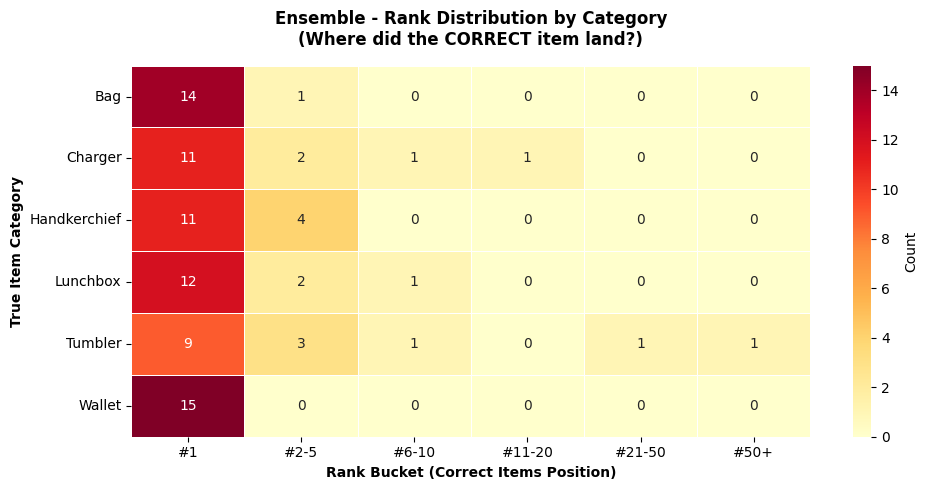


PER-CATEGORY ITEM-LEVEL ACCURACY (ENSEMBLE)
Per category: correct items at rank #1 vs wrong items with details.

  Category           R@1 Correct    Wrong at R@1 (true item -> AI top-1 guess, rank)
  --------------- --------------  --------------------------------------------------
  Bag                         14                                bag_058->bag_057(#3)
  Charger                     11  charger_038->charger_030(#4), charger_040->charger_064(#20), charger_081->charger_070(#6), charger_083->charger_071(#2)
  Handkerchief                11  handkerchief_027->handkerchief_079(#5), handkerchief_034->handkerchief_083(#2), handkerchief_035->handkerchief_087(#5), handkerchief_062->handkerchief_098(#2)
  Lunchbox                    12  lunchbox_050->lunchbox_030(#6), lunchbox_075->lunchbox_100(#2), lunchbox_079->lunchbox_074(#2)
  Tumbler                      9  tumbler_047->tumbler_050(#26), tumbler_065->tumbler_051(#83), tumbler_066->tumbler_007(#8), tumbler_084->tumbler_086(#2),

NameError: name 'failed_r1' is not defined

In [12]:
# ================================================================
# CELL 6: Rank Distribution Matrix & Per-Category Item Accuracy
#
#   WHY we replaced the category confusion matrix with this:
#   The old matrix compared true_category vs predicted_category.
#   With ~80% R@1 and 6 categories (15 items each), the model
#   almost always retrieves the correct category even when it
#   retrieves the WRONG item (e.g. charger_030 instead of charger_040).
#   So the matrix was perfectly diagonal -- hiding the fact that
#   20% of items were wrong at rank #1.
#
#   New visualizations:
#   1. RANK DISTRIBUTION MATRIX: rows = true category, cols = rank buckets.
#      Shows WHERE the correct item landed, not just whether the
#      predicted category was correct.
#
#   2. PER-CATEGORY ITEM-LEVEL ACCURACY: for each category, shows
#      which specific items were confused with which.
#      This is what reveals the 20% item-level failure.
# ================================================================

unique_cats = sorted(list(set(results_ens['true_categories'])))

# Build per-query rank data
cat_rank_data = {cat: [] for cat in unique_cats}
for i in range(num_test_items):
    target_name = test_item_names[i]
    correct_match_idx = gallery_item_names.index(target_name)
    ranked_indices = np.argsort(sim_matrix[i])[::-1]
    actual_rank = int(np.where(ranked_indices == correct_match_idx)[0][0] + 1)
    top1_item = gallery_item_names[ranked_indices[0]]
    cat = target_name.split('_')[0].capitalize()
    cat_rank_data[cat].append({
        'item': target_name,
        'rank': actual_rank,
        'top1_item': top1_item,
        'top1_correct': (top1_item == target_name)
    })

# ---- Matrix 1: Rank Distribution ----
rank_buckets = ['#1', '#2-5', '#6-10', '#11-20', '#21-50', '#50+']
bucket_edges = [1, 2, 6, 11, 21, 51, 999]

def bucket_for(rank):
    for j in range(len(bucket_edges) - 1):
        if rank >= bucket_edges[j] and rank < bucket_edges[j+1]:
            return rank_buckets[j]
    return rank_buckets[-1]

dist_matrix = np.zeros((len(unique_cats), len(rank_buckets)), dtype=int)
for ci, cat in enumerate(unique_cats):
    for record in cat_rank_data[cat]:
        bi = rank_buckets.index(bucket_for(record['rank']))
        dist_matrix[ci, bi] += 1

print("")
print("="*60)
print("RANK DISTRIBUTION MATRIX (ENSEMBLE)")
print("="*60)
print("Rows = true item category. Cols = rank bucket where the")
print("CORRECT ITEM ended up (not the predicted category).")
print()
dist_df = pd.DataFrame(dist_matrix, index=unique_cats, columns=rank_buckets)
dist_df.index.name = 'Category'
print(dist_df)
print()
print(f"  {'Category':<15} {'R@1 Acc':>8} {'Avg Rank':>10} {'Worst Rank':>12}")
print(f"  {'-'*15} {'-'*8} {'-'*10} {'-'*12}")
for cat in unique_cats:
    ranks = [r['rank'] for r in cat_rank_data[cat]]
    r1_acc = sum(1 for r in ranks if r == 1) / len(ranks) * 100
    avg_r  = sum(ranks) / len(ranks)
    worst  = max(ranks)
    print(f"  {cat:<15} {r1_acc:>7.1f}% {avg_r:>10.1f} {'#'+str(worst):>12}")

# Heatmap
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(dist_df, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Count'})
ax.set_title('Ensemble - Rank Distribution by Category\n(Where did the CORRECT item land?)', fontweight='bold', pad=15)
ax.set_xlabel('Rank Bucket (Correct Items Position)', fontweight='bold')
ax.set_ylabel('True Item Category', fontweight='bold')
plt.tight_layout()
plt.show()

# ---- Matrix 2: Per-category item-level accuracy ----
print()
print("="*60)
print("PER-CATEGORY ITEM-LEVEL ACCURACY (ENSEMBLE)")
print("="*60)
print("Per category: correct items at rank #1 vs wrong items with details.")
print()
print(f"  {'Category':<15} {'R@1 Correct':>14}  {'Wrong at R@1 (true item -> AI top-1 guess, rank)':>50}")
print(f"  {'-'*15} {'-'*14}  {'-'*50}")
for cat in unique_cats:
    correct_items = [r for r in cat_rank_data[cat] if r['top1_correct']]
    wrong_items  = [r for r in cat_rank_data[cat] if not r['top1_correct']]
    if wrong_items:
        wrong_str = ', '.join(f"{r['item']}->{r['top1_item']}(#{r['rank']})" for r in wrong_items)
    else:
        wrong_str = '-'
    print(f"  {cat:<15} {len(correct_items):>14}  {wrong_str:>50}")

cat_level_correct = sum(1 for i in range(num_test_items)
    if results_ens['true_categories'][i] == results_ens['predicted_categories'][i])
cat_level_wrong   = num_test_items - cat_level_correct
item_level_correct = num_test_items - len(failed_r1)
print()
print(f"  NOTE: What the old category confusion matrix showed:")
print(f"        Category-level accuracy: {cat_level_correct}/{num_test_items} ({cat_level_correct/num_test_items*100:.1f}%)")
print(f"        ITEM-level R@1 accuracy: {item_level_correct}/{num_test_items} ({item_level_correct/num_test_items*100:.1f}%)")
print(f"        The category matrix HID {cat_level_wrong} item-level failures.")
print()
print(f"  WHY: When model retrieves charger_030 instead of charger_040,")
print(f"       it is still a 'correct' category prediction (Charger->Charger)")
print(f"       even though the item-level R@1 is wrong.")
print("="*60)
print("Rank distribution & item-level accuracy displayed.")


In [ ]:
# ================================================================
# CELL 7: Comprehensive Failure Analysis - Ensemble
# ================================================================
failed_r1 = []
failed_r5 = []
failed_r10 = []

print("")
print("="*60)
print("ENSEMBLE - COMPREHENSIVE FAILURE ANALYSIS")
print("="*60)

for i in range(num_test_items):
    target_name = test_item_names[i]
    correct_match_idx = gallery_item_names.index(target_name)

    query_scores   = sim_matrix[i]
    ranked_indices = np.argsort(query_scores)[::-1]

    actual_rank = np.where(ranked_indices == correct_match_idx)[0][0] + 1

    if actual_rank > 1:
        failed_r1.append(i)

        if actual_rank > 10:
            severity = "FAILED RECALL@10"
            failed_r10.append(i)
        elif actual_rank > 5:
            severity = "FAILED RECALL@5 (But passed R@10)"
            failed_r5.append(i)
        else:
            severity = "Failed R@1 (But passed R@5)"

        print(f"")
        print(f"Index: {i}  [{severity}]")
        print(f"   True Rank:     #{actual_rank}")
        print(f"   Text Query:    '{queries[i]}'")
        print(f"   Correct Image: {target_name}")
        print(f"   AI #1 Guess:   {gallery_item_names[ranked_indices[0]]}")

print("")
print("="*60)
print("FAILURE SUMMARY (ENSEMBLE)")
print("="*60)
print(f"  Total Queries that failed R@1:  {len(failed_r1)}")
print(f"  Total Queries that failed R@5:  {len(failed_r5)}")
print(f"  Total Queries that failed R@10: {len(failed_r10)} -> Indices: {failed_r10}")
print("="*60)


In [ ]:
# ================================================================
# CELL 8: Per-Query Rank Comparison - Ensemble vs Individual Models
#
#   Shows which queries the ensemble improved, and which it hurt.
#   Focus especially on the boundary cases: charger_040 and charger_081.
# ================================================================

ranks_A   = results_A['per_query_ranks']
ranks_B   = results_B['per_query_ranks']
ranks_ens = results_ens['per_query_ranks']

# --- Hard-case focus table ---
known_hard = ['tumbler_047', 'tumbler_065', 'charger_040', 'charger_081', 'lunchbox_050']

print("")
print("="*75)
print("FOCUS: KNOWN HARD CASES - Rank per Model")
print("="*75)
print(f"  {'Item':<18} {'V2.1 HNM':>10} {'CLAUDE HNM':>12} {'ENSEMBLE':>10}  {'Change vs Best':>18}  {'Status':>20}")
print(f"  {'-'*18} {'-'*10} {'-'*12} {'-'*10}  {'-'*18}  {'-'*20}")

for item in known_hard:
    r_A   = ranks_A[item]
    r_B   = ranks_B[item]
    r_ens = ranks_ens[item]
    best_single = min(r_A, r_B)
    change = r_ens - best_single
    change_str = f"{'+' if change < 0 else ''}{change}"  # negative = better
    if r_ens <= 10 and best_single > 10:
        status = "RECOVERED by ensemble"
    elif r_ens > 10:
        status = "still severe (>R@10)"
    else:
        status = "no change"
    print(f"  {item:<18} {'#'+str(r_A):>10} {'#'+str(r_B):>12} {'#'+str(r_ens):>10}  {change_str:>18}  {status:>20}")

print("="*75)

# --- Full per-query improvement table ---
print("")
print("="*75)
print("FULL PER-QUERY RANK COMPARISON (sorted by V2.1+HNM rank, worst first)")
print("="*75)
print(f"  {'Test Item':<20} {'V2.1 HNM':>10} {'CLAUDE HNM':>12} {'ENSEMBLE':>10}  {'Notes':>30}")
print(f"  {'-'*20} {'-'*10} {'-'*12} {'-'*10}  {'-'*30}")

items_sorted = sorted(
    [(item, ranks_A[item], ranks_B[item], ranks_ens[item]) for item in test_item_names],
    key=lambda x: x[1]
)

for item, r_A, r_B, r_ens in items_sorted:
    best_single = min(r_A, r_B)
    delta = r_ens - best_single

    if r_A <= 10 and r_B <= 10:
        note = "both recover"
    elif r_A <= 10:
        note = "A recovers (B fails)"
    elif r_B <= 10:
        note = "B recovers (A fails)"
    elif r_ens <= 10:
        note = "ensemble recovers"
    elif r_ens < min(r_A, r_B):
        note = f"improved by {abs(delta)}"
    elif r_ens > max(r_A, r_B):
        note = f"worse by {abs(delta)}"
    else:
        note = "no change"

    print(f"  {item:<20} {'#'+str(r_A):>10} {'#'+str(r_B):>12} {'#'+str(r_ens):>10}  {note:>30}")

print("="*75)


In [ ]:
# ================================================================
# CELL 9: Investigate a Specific Query
#
#   Uncomment and set the query string to inspect a specific item.
# ================================================================
# search_query = "tumbler_047"
#
# match_idx = None
# for i, name in enumerate(test_item_names):
#     if name == search_query:
#         match_idx = i
#         break
#
# if match_idx is not None:
#     print(f"Fixed query matched test index: {match_idx}")
#     print(f"  Query:      '{queries[match_idx]}'")
#     print(f"  True match: {test_item_names[match_idx]}")
#     print(f"  V2.1+HNM rank:   #{ranks_A[search_query]}")
#     print(f"  CLAUDE+HNM rank: #{ranks_B[search_query]}")
#     print(f"  Ensemble rank:   #{ranks_ens[search_query]}")
# else:
#     print(f"No match found for '{search_query}'")


In [ ]:
# ================================================================
# CELL 10: Summary - Ensemble Results vs All Prior Models
# ================================================================
print("")
print("="*65)
print("ENSEMBLE vs ALL PRIOR MODELS - COMPLETE COMPARISON")
print("="*65)
print(f"  {'Model':<32} {'R@1':>7} {'R@5':>7} {'R@10':>7} {'MRR':>8} {'Severe':>8}")
print(f"  {'-'*32} {'-'*7} {'-'*7} {'-'*7} {'-'*8} {'-'*8}")
print(f"  {'V1':<32} {'71.11%':>7} {'91.11%':>7} {'93.33%':>7} {'0.8017':>8} {'6':>8}")
print(f"  {'V2':<32} {'80.00%':>7} {'92.22%':>7} {'95.56%':>7} {'0.8606':>8} {'4':>8}")
print(f"  {'V2 + HNM':<32} {'78.89%':>7} {'91.11%':>7} {'96.67%':>7} {'0.8556':>8} {'3':>8}")
print(f"  {'V2.1 + HNM':<32} {'80.00%':>7} {'92.22%':>7} {'96.67%':>7} {'0.8615':>8} {'3':>8}")
print(f"  {'CLAUDE V2 + HNM':<32} {'77.78%':>7} {'91.11%':>7} {'96.67%':>7} {'0.8515':>8} {'3':>8}")
print(f"  {'CLAUDE V2.1 + HNM':<32} {'78.89%':>7} {'94.44%':>7} {'96.67%':>7} {'0.8615':>8} {'3':>8}")
print(f"  {'-'*32} {'-'*7} {'-'*7} {'-'*7} {'-'*8} {'-'*8}")
print(f"  {'ENSEMBLE (V2.1+HNM + CLAUDE V2.1+HNM)':<32} {results_ens['r1']:>6.2f}% {results_ens['r5']:>6.2f}% {results_ens['r10']:>6.2f}% {results_ens['mrr']:>8.4f} {len(failed_r10):>8}")
print(f"{'='*65}")
print()
print(f"  Key boundary cases (from Model Logs.md):")
print(f"  - charger_040: V2.1=#16, CLAUDE=#8  -> ensemble expected: top 10")
print(f"  - charger_081: V2.1=recovered, CLAUDE=recovered -> expected: recovered")
print(f"  - tumbler_047: V2.1=#33, CLAUDE=#26 -> ensemble expected: near #26 or better")
print(f"  - tumbler_065: V2.1=#86, CLAUDE=#80 -> ensemble expected: near #80 or better")
print()
print(f"  Severe failures: items where correct item is NOT in top 10.")
print(f"  Run CELL 7 to see actual severe failure count after encoding.")
print("="*65)
